# Gradient Descent for Simple Linear Regression

## Goal

Learn how a linear-regression model moves from an initial line to the best-fit line. By the end, you will be able to:

- explain derivatives and gradients using slope intuition;
- apply the update $\theta_j\leftarrow\theta_j-\alpha\,\partial J/\partial\theta_j$;
- understand positive and negative gradients;
- choose and diagnose a learning rate;
- derive the gradients for the intercept and slope;
- implement gradient descent from scratch;
- recognize convergence and common failure modes.

**Source material:** the supplied continuation transcript and *Simple Linear Regression* slides. Repeated speech is removed and technical statements are corrected where needed.


## 1. Why do we need an optimization algorithm?

Trying random values such as $\theta_1=1$, $0.5$, and $0$ can illustrate the cost function, but it is not an efficient training method.

We need a repeatable rule that:

1. starts from initial parameter values;
2. measures the current cost;
3. determines which direction decreases the cost;
4. updates the parameters;
5. repeats until the improvement becomes negligible.

That rule is **gradient descent**. “Convergence algorithm” in the transcript refers to this iterative optimization process.

> The U-shaped or bowl-shaped graph is the **cost curve/surface**. Gradient descent is the movement rule used on that surface.


## 2. Derivative = local slope

For a one-variable function, the derivative tells us the slope of the tangent at the current point.

- derivative $<0$: the curve slopes downward as the parameter increases;
- derivative $>0$: the curve slopes upward as the parameter increases;
- derivative $=0$: the curve is locally flat; for a convex quadratic cost, this is the minimum.

A familiar power rule is:

$$\frac{d}{dx}x^n=nx^{n-1}$$

Therefore:

$$\frac{d}{dx}x^2=2x$$

With several parameters, a **partial derivative** changes one parameter while treating the others as fixed. The vector of all partial derivatives is the **gradient**.


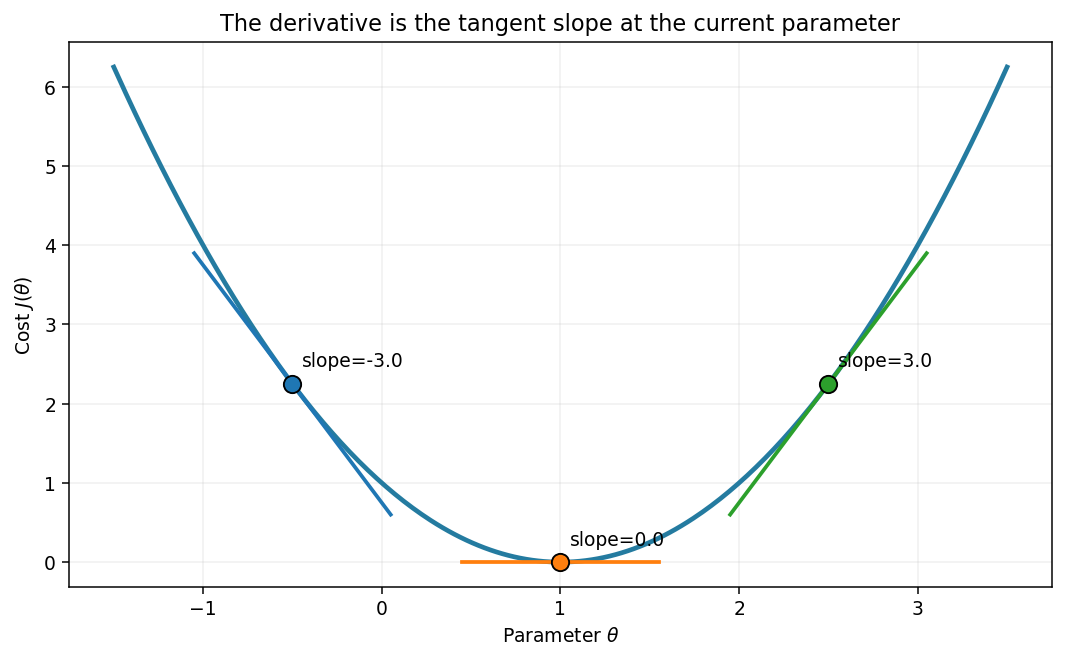

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A simple quadratic: J(theta) = (theta - 1)^2
theta = np.linspace(-1.5, 3.5, 300)
cost = (theta - 1) ** 2

sample_points = [-0.5, 1.0, 2.5]
plt.figure(figsize=(8, 5))
plt.plot(theta, cost, linewidth=2.5, color="#247BA0")
for point in sample_points:
    value = (point - 1) ** 2
    derivative = 2 * (point - 1)
    tangent_x = np.linspace(point - 0.55, point + 0.55, 30)
    tangent_y = value + derivative * (tangent_x - point)
    plt.plot(tangent_x, tangent_y, linewidth=2)
    plt.scatter(point, value, s=85, edgecolor="black", zorder=3)
    plt.annotate(f"slope={derivative:.1f}", (point, value), xytext=(5, 9), textcoords="offset points")
plt.xlabel(r"Parameter $\theta$")
plt.ylabel(r"Cost $J(\theta)$")
plt.title("The derivative is the tangent slope at the current parameter")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 3. The gradient-descent update

For parameter $\theta_j$:

$$
\boxed{\theta_j\leftarrow\theta_j-\alpha\frac{\partial J(\boldsymbol{\theta})}{\partial\theta_j}}
$$

- $\theta_j$: one current parameter;
- $J$: the cost function;
- $\partial J/\partial\theta_j$: cost's slope with respect to that parameter;
- $\alpha>0$: the **learning rate**, controlling step size;
- $\leftarrow$: replace the old value with the new value.

### Why subtraction moves downhill

- If the gradient is **negative**, subtracting it adds a positive amount, so $\theta_j$ increases.
- If the gradient is **positive**, subtracting it decreases $\theta_j$.
- Near the minimum, the gradient becomes small, so updates naturally become smaller.

The negative gradient points in the direction of steepest local decrease.


Parameter path: [-1.0, -0.2, 0.28, 0.568, 0.7408, 0.8445, 0.9067, 0.944, 0.9664, 0.9798, 0.9879, 0.9927, 0.9956]
Final cost: 1.895e-05


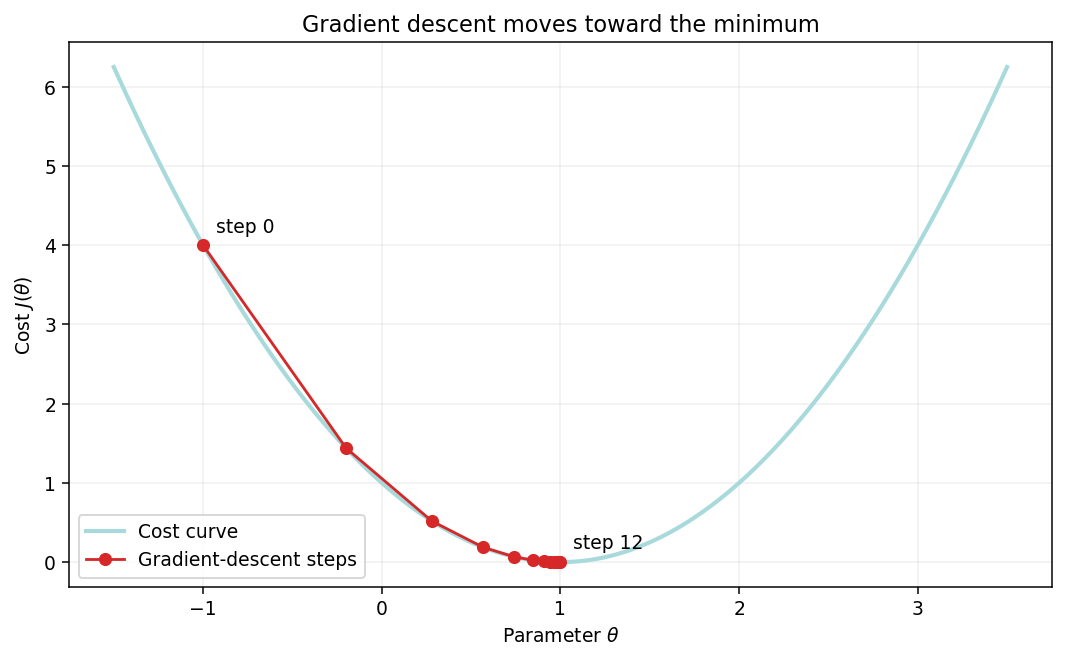

In [2]:
def run_quadratic_descent(start, learning_rate, steps):
    current = float(start)
    history = [current]
    for _ in range(steps):
        gradient = 2 * (current - 1)  # derivative of (theta - 1)^2
        current = current - learning_rate * gradient
        history.append(current)
    return np.array(history)


path = run_quadratic_descent(start=-1.0, learning_rate=0.2, steps=12)
print("Parameter path:", np.round(path, 4).tolist())
print("Final cost:", round((path[-1] - 1) ** 2, 8))

plt.figure(figsize=(8, 5))
plt.plot(theta, cost, linewidth=2.2, color="#A8DADC", label="Cost curve")
plt.plot(path, (path - 1) ** 2, "o-", color="#D62828", label="Gradient-descent steps")
for index in [0, len(path) - 1]:
    plt.annotate(f"step {index}", (path[index], (path[index] - 1) ** 2),
                 xytext=(7, 7), textcoords="offset points")
plt.xlabel(r"Parameter $\theta$")
plt.ylabel(r"Cost $J(\theta)$")
plt.title("Gradient descent moves toward the minimum")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Learning rate $\alpha$

The learning rate controls how far each update moves.

- **Too small:** stable but requires many iterations.
- **Suitable:** reaches the minimum efficiently.
- **Too large:** overshoots, oscillates, or diverges.

There is no universal best learning rate such as `0.001`. A suitable value depends on feature scale, the cost surface, the optimizer, and the data. Test candidate values and monitor the cost.

Also, ordinary closed-form linear-regression implementations do not necessarily use gradient descent at all. A learning rate matters only when the chosen fitting algorithm is iterative.


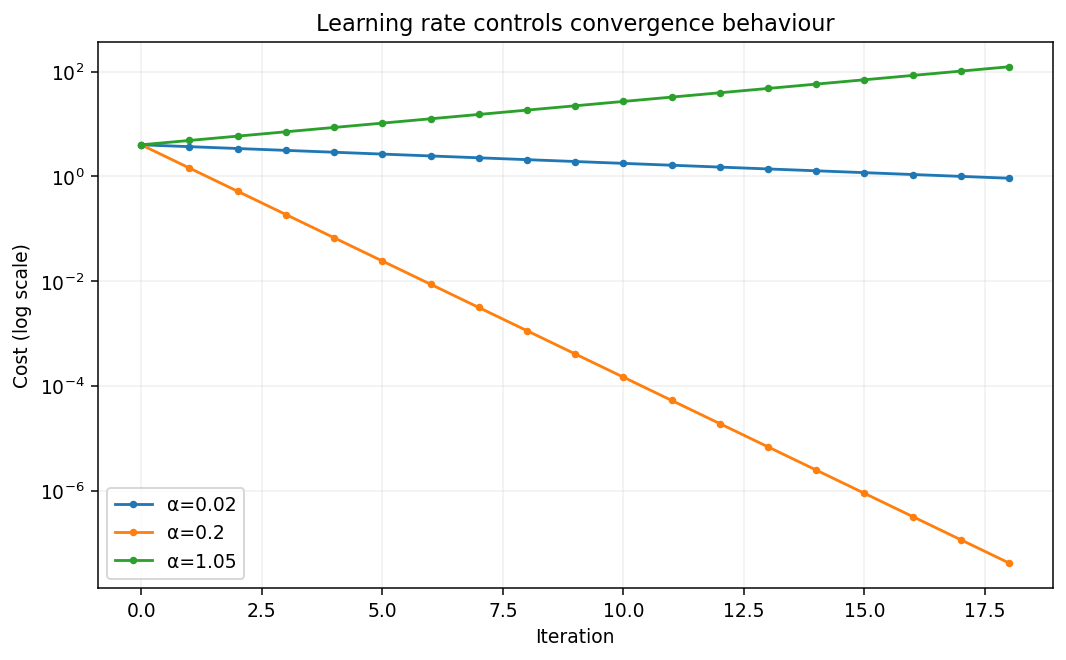

In [3]:
learning_rates = [0.02, 0.20, 1.05]

plt.figure(figsize=(8, 5))
for lr in learning_rates:
    lr_path = run_quadratic_descent(start=-1.0, learning_rate=lr, steps=18)
    lr_costs = (lr_path - 1) ** 2
    plt.plot(range(len(lr_costs)), lr_costs, marker="o", markersize=3, label=f"α={lr}")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Cost (log scale)")
plt.title("Learning rate controls convergence behaviour")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


## 5. Linear-regression cost and gradients

The hypothesis is:

$$h_\theta(x^{(i)})=\theta_0+\theta_1x^{(i)}$$

The half-MSE cost is:

$$
J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)^2
$$

Using the chain rule gives:

$$
\boxed{\frac{\partial J}{\partial\theta_0}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)}
$$

$$
\boxed{\frac{\partial J}{\partial\theta_1}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)x^{(i)}}
$$

Why the formulas differ: $\partial h/\partial\theta_0=1$, while $\partial h/\partial\theta_1=x$.


## 6. Update both parameters simultaneously

At each iteration, calculate both gradients using the **same old** values of $\theta_0$ and $\theta_1$:

$$
\text{temp}_0=\theta_0-\alpha\frac{1}{m}\sum_i(\hat y^{(i)}-y^{(i)})
$$

$$
\text{temp}_1=\theta_1-\alpha\frac{1}{m}\sum_i(\hat y^{(i)}-y^{(i)})x^{(i)}
$$

Then assign:

$$\theta_0\leftarrow\text{temp}_0,\qquad\theta_1\leftarrow\text{temp}_1$$

Using the updated $\theta_0$ to calculate the old iteration's $\theta_1$ update silently changes the algorithm.


In [4]:
def half_mse(x, y, theta_0, theta_1):
    errors = theta_0 + theta_1 * x - y
    return np.mean(errors ** 2) / 2


def gradient_descent_linear(x, y, learning_rate=0.08, max_iterations=3000, tolerance=1e-12):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    theta_0 = 0.0
    theta_1 = 0.0
    history = []

    for iteration in range(max_iterations):
        predictions = theta_0 + theta_1 * x
        errors = predictions - y
        gradient_0 = errors.mean()
        gradient_1 = np.mean(errors * x)
        cost_before = np.mean(errors ** 2) / 2

        # Simultaneous updates: both use gradients from the old parameters
        new_theta_0 = theta_0 - learning_rate * gradient_0
        new_theta_1 = theta_1 - learning_rate * gradient_1
        history.append((iteration, theta_0, theta_1, cost_before))

        parameter_change = max(abs(new_theta_0 - theta_0), abs(new_theta_1 - theta_1))
        theta_0, theta_1 = new_theta_0, new_theta_1
        if parameter_change < tolerance:
            break

    history.append((iteration + 1, theta_0, theta_1, half_mse(x, y, theta_0, theta_1)))
    return theta_0, theta_1, np.array(history)


x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_train = np.array([2.1, 4.1, 5.9, 8.2, 9.8])
theta_0, theta_1, history = gradient_descent_linear(x_train, y_train)

print(f"Iterations: {int(history[-1, 0])}")
print(f"Learned intercept theta_0: {theta_0:.6f}")
print(f"Learned slope theta_1:     {theta_1:.6f}")
print(f"Final half-MSE cost:        {history[-1, 3]:.8f}")


Iterations: 1636
Learned intercept theta_0: 0.170000
Learned slope theta_1:     1.950000
Final half-MSE cost:        0.00830000


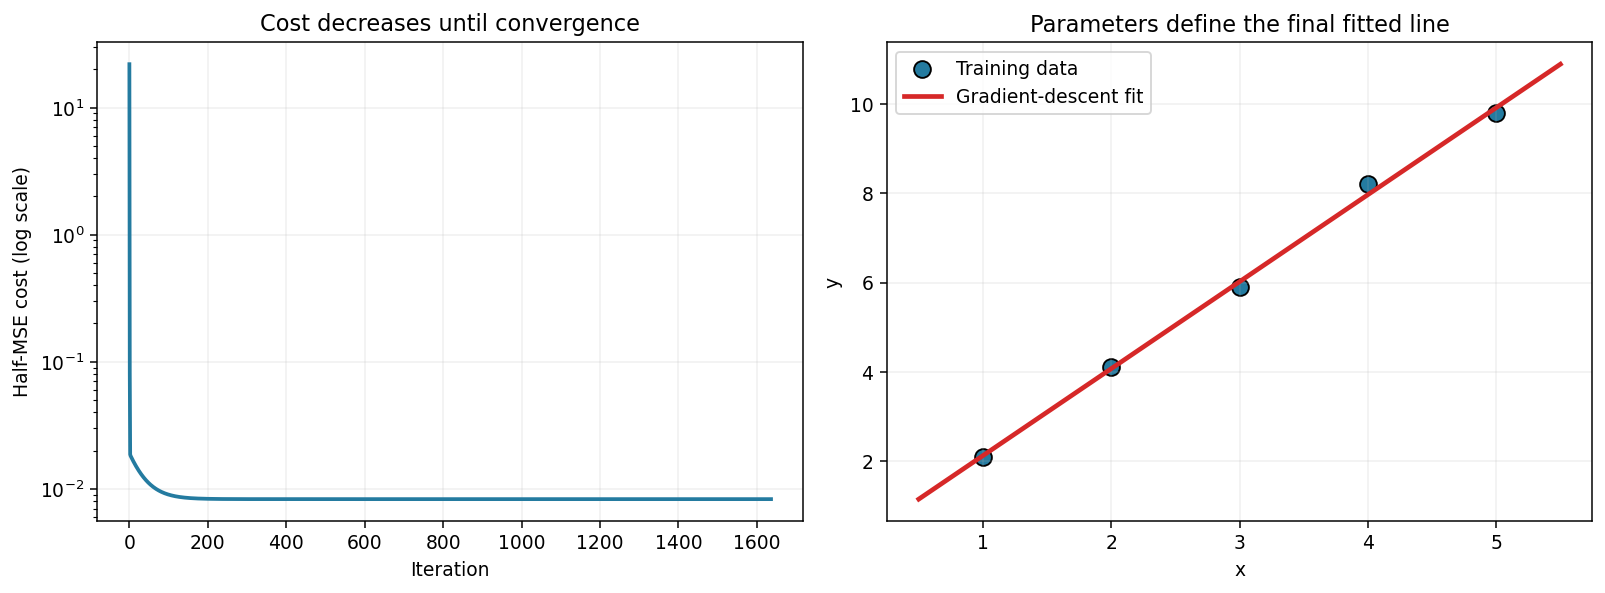

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Cost over iterations
axes[0].plot(history[:, 0], history[:, 3], color="#247BA0", linewidth=2)
axes[0].set_yscale("log")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Half-MSE cost (log scale)")
axes[0].set_title("Cost decreases until convergence")
axes[0].grid(alpha=0.2)

# Final best-fit line
x_line = np.linspace(0.5, 5.5, 150)
axes[1].scatter(x_train, y_train, s=80, color="#247BA0", edgecolor="black", label="Training data")
axes[1].plot(x_line, theta_0 + theta_1 * x_line, color="#D62828", linewidth=2.5, label="Gradient-descent fit")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Parameters define the final fitted line")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Two parameters create a cost surface

When the intercept is fixed at zero, plotting $J$ against $\theta_1$ gives a 2D graph. When both $\theta_0$ and $\theta_1$ change, $J(\theta_0,\theta_1)$ forms a 3D bowl-shaped surface for ordinary linear regression.

Each point on the surface represents:

- one intercept value;
- one slope value;
- the resulting cost.

The gradient has two components and points uphill; the negative gradient points downhill. Because the ordinary squared-error surface for linear regression is convex, every local minimum is also a global minimum. It may be a flat set rather than one unique point if the features are redundant.


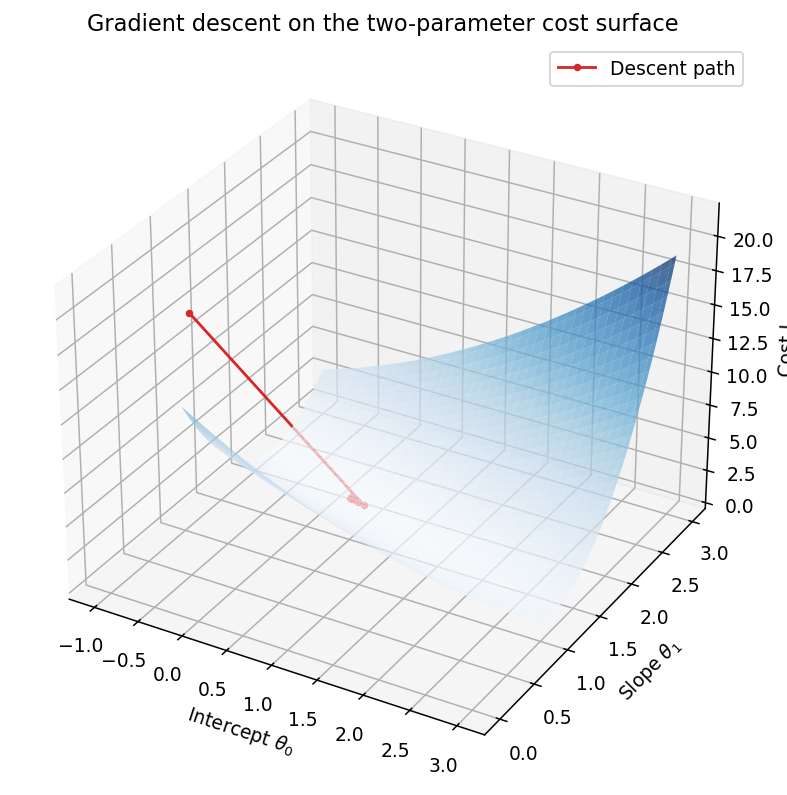

In [6]:
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

theta0_values = np.linspace(-1.0, 3.0, 80)
theta1_values = np.linspace(1.0, 3.0, 80)
theta0_grid, theta1_grid = np.meshgrid(theta0_values, theta1_values)
cost_grid = np.zeros_like(theta0_grid)

for row in range(cost_grid.shape[0]):
    for col in range(cost_grid.shape[1]):
        cost_grid[row, col] = half_mse(
            x_train, y_train, theta0_grid[row, col], theta1_grid[row, col]
        )

sampled_history = history[::max(1, len(history) // 35)]

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(theta0_grid, theta1_grid, cost_grid, cmap="Blues", alpha=0.72, edgecolor="none")
ax.plot(sampled_history[:, 1], sampled_history[:, 2], sampled_history[:, 3],
        "o-", color="#D62828", markersize=3, linewidth=1.5, label="Descent path")
ax.set_xlabel(r"Intercept $\theta_0$")
ax.set_ylabel(r"Slope $\theta_1$")
ax.set_zlabel("Cost J")
ax.set_title("Gradient descent on the two-parameter cost surface")
ax.legend()
plt.tight_layout()
plt.show()


## 8. When should training stop?

“Repeat until convergence” must become a precise program rule. Common choices are:

- stop after a maximum number of iterations;
- stop when the absolute cost improvement is below a tolerance;
- stop when every parameter update is below a tolerance;
- stop when the gradient norm is below a tolerance;
- use early stopping when validation performance stops improving.

Always store or plot the cost. If it rises repeatedly, suspect an excessive learning rate, incorrect gradients, unscaled features, or a coding error.


## 9. Practical improvements and variants

### Feature scaling

Large feature values create steep gradients. Standardizing $x$ often makes gradient descent more stable and allows a more useful learning rate.

### Batch variants

- **Batch gradient descent:** uses all $m$ rows for each update; this is the version derived above.
- **Stochastic gradient descent:** uses one row per update; noisy but cheap and useful for large/streaming data.
- **Mini-batch gradient descent:** uses a small group of rows; common in deep learning.

### Vector form

For several features, with design matrix $X$ and parameter vector $\boldsymbol\theta$:

$$\hat{\mathbf y}=X\boldsymbol\theta$$

$$\nabla J=\frac{1}{m}X^T(X\boldsymbol\theta-\mathbf y)$$

$$\boldsymbol\theta\leftarrow\boldsymbol\theta-\alpha\nabla J$$

This is the same logic as the two scalar update equations.


## 10. Common mistakes

1. Calling the cost curve “gradient descent.” Gradient descent is the update algorithm.
2. Writing the derivative backwards. The standard notation is $\partial J/\partial\theta_j$.
3. Forgetting the factor $x^{(i)}$ in the slope gradient.
4. Updating $\theta_0$ before calculating the old iteration's $\theta_1$ update.
5. Assuming `0.001` is always the correct learning rate.
6. Stopping without checking whether the cost stabilized.
7. Ignoring feature scale when training diverges or crawls.
8. Assuming every model's cost is convex. Linear-regression squared error is convex; neural-network loss surfaces generally are not.


## 11. Quick revision sheet

- **Gradient:** vector of partial derivatives of the cost.
- **Learning rate:** $\alpha$, the step-size multiplier.
- **Update:** $\theta_j\leftarrow\theta_j-\alpha\,\partial J/\partial\theta_j$.
- **Negative derivative:** update increases the parameter.
- **Positive derivative:** update decreases the parameter.
- **Intercept gradient:** $\frac{1}{m}\sum_i(\hat y^{(i)}-y^{(i)})$.
- **Slope gradient:** $\frac{1}{m}\sum_i(\hat y^{(i)}-y^{(i)})x^{(i)}$.
- **Convergence:** updates, gradient, or cost improvement becomes sufficiently small.
- **Too-small $\alpha$:** slow.
- **Too-large $\alpha$:** oscillation or divergence.
- **Linear-regression squared-error cost:** convex.


## 12. Quick questions — answer before checking below

1. Why is manually testing random slopes inefficient?
2. What does a derivative tell us at one point on a curve?
3. Write the general gradient-descent update.
4. What does $\alpha$ control?
5. If the derivative is negative, does the parameter increase or decrease after the update?
6. If the derivative is positive, does the parameter increase or decrease?
7. What can happen when the learning rate is too small?
8. What can happen when it is too large?
9. Is `0.001` always the best learning rate?
10. Write $\partial J/\partial\theta_0$ for simple linear regression.
11. Write $\partial J/\partial\theta_1$.
12. Why does the slope gradient contain $x^{(i)}$?
13. Why should $\theta_0$ and $\theta_1$ be updated simultaneously?
14. Why is the ordinary linear-regression cost surface friendly to gradient descent?
15. Name two reasonable convergence criteria.


## 13. Answer key

1. It does not systematically use the cost's direction or slope and scales poorly to many parameter values.
2. The local slope—the direction and rate at which the function changes.
3. $\theta_j\leftarrow\theta_j-\alpha\,\partial J/\partial\theta_j$.
4. The size of each optimization step.
5. It increases because subtracting a negative gradient adds a positive quantity.
6. It decreases.
7. Training converges very slowly.
8. Updates can overshoot, oscillate, or diverge.
9. No. It depends on the data scale and optimizer.
10. $\frac{1}{m}\sum_i(\hat y^{(i)}-y^{(i)})$.
11. $\frac{1}{m}\sum_i(\hat y^{(i)}-y^{(i)})x^{(i)}$.
12. Because $\partial(\theta_0+\theta_1x)/\partial\theta_1=x$.
13. Both updates must use gradients calculated from the same old parameter pair; otherwise the intended algorithm changes.
14. With squared error it is convex, so it has no bad local minima.
15. Examples: maximum iterations, tiny cost improvement, tiny parameter change, or small gradient norm.
